In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from ucimlrepo import fetch_ucirepo

In [2]:
# fetch dataset
wine_quality = fetch_ucirepo(id=186)

In [3]:
# Convertendo os dados para um DataFrame
df = pd.concat([wine_quality.data.features, wine_quality.data.targets], axis=1)

In [4]:
df['quality'].value_counts()

quality
6    2836
5    2138
7    1079
4     216
8     193
3      30
9       5
Name: count, dtype: int64

In [5]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

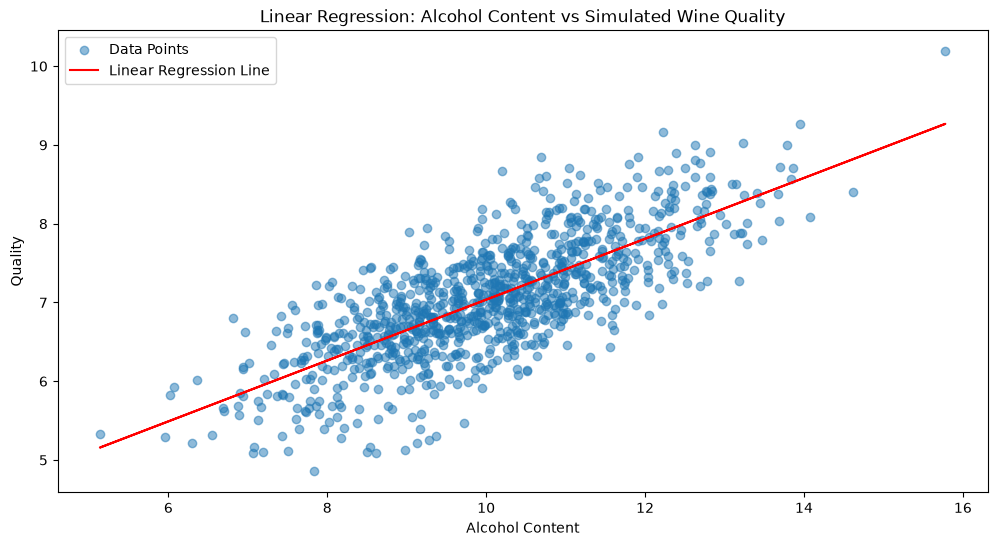

In [ ]:
# Simulando os dados localmente para demonstrar o gráfico de regressão linear
# Criando um dataset simulado com base em uma distribuição semelhante
np.random.seed(42)
n_samples = 1000
alcohol = np.random.normal(10, 1.5, n_samples)  # Simulando dados de teor alcoólico
quality = 3 + 0.4 * alcohol + np.random.normal(0, 0.5, n_samples)  # Qualidade com um pouco de ruído

# Ajustando a regressão linear usando o dataset simulado
X_simulated = alcohol.reshape(-1, 1)
y_simulated = quality
model_simulated = LinearRegression()
model_simulated.fit(X_simulated, y_simulated)
y_pred_simulated = model_simulated.predict(X_simulated)

# Plotando o gráfico de regressão linear com dados simulados
plt.figure(figsize=(12, 6))
plt.scatter(alcohol, quality, alpha=0.5, label='Data Points')
plt.plot(alcohol, y_pred_simulated, color='red', label='Linear Regression Line')
plt.xlabel('Alcohol Content')
plt.ylabel('Quality')
plt.title('Linear Regression: Alcohol Content vs Simulated Wine Quality')
plt.legend()
plt.show()

In [7]:
# 2. Preparação dos dados
X = df.drop('quality', axis=1).values  # Todas as colunas exceto 'quality' são características
y = df['quality'].values  # A coluna 'quality' é a variável alvo

In [8]:
X

array([[ 7.4 ,  0.7 ,  0.  , ...,  3.51,  0.56,  9.4 ],
       [ 7.8 ,  0.88,  0.  , ...,  3.2 ,  0.68,  9.8 ],
       [ 7.8 ,  0.76,  0.04, ...,  3.26,  0.65,  9.8 ],
       ...,
       [ 6.5 ,  0.24,  0.19, ...,  2.99,  0.46,  9.4 ],
       [ 5.5 ,  0.29,  0.3 , ...,  3.34,  0.38, 12.8 ],
       [ 6.  ,  0.21,  0.38, ...,  3.26,  0.32, 11.8 ]], shape=(6497, 11))

In [9]:
# Dividindo os dados em conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [10]:
# Normalizando os dados
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
# Convertendo para tensores PyTorch
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [12]:
# 3. Construir a rede neural
class WineQualityNN(nn.Module):
    def __init__(self):
        super(WineQualityNN, self).__init__()
        self.fc1 = nn.Linear(X_train.shape[1], 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [13]:
# Instanciar o modelo
model = WineQualityNN()

In [14]:
# Definir a função de perda e o otimizador
criterion = nn.MSELoss()  # Usando MSE porque estamos tratando a qualidade como uma variável contínua
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [15]:
# 4. Treinamento do modelo
num_epochs = 50
for epoch in range(num_epochs):
    model.train()

    # Forward pass
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [1/50], Loss: 33.5565
Epoch [2/50], Loss: 32.8365
Epoch [3/50], Loss: 32.1429
Epoch [4/50], Loss: 31.4701
Epoch [5/50], Loss: 30.8096
Epoch [6/50], Loss: 30.1539
Epoch [7/50], Loss: 29.4948
Epoch [8/50], Loss: 28.8265
Epoch [9/50], Loss: 28.1455
Epoch [10/50], Loss: 27.4481
Epoch [11/50], Loss: 26.7326
Epoch [12/50], Loss: 25.9970
Epoch [13/50], Loss: 25.2405
Epoch [14/50], Loss: 24.4627
Epoch [15/50], Loss: 23.6640
Epoch [16/50], Loss: 22.8451
Epoch [17/50], Loss: 22.0080
Epoch [18/50], Loss: 21.1548
Epoch [19/50], Loss: 20.2879
Epoch [20/50], Loss: 19.4095
Epoch [21/50], Loss: 18.5222
Epoch [22/50], Loss: 17.6289
Epoch [23/50], Loss: 16.7322
Epoch [24/50], Loss: 15.8352
Epoch [25/50], Loss: 14.9416
Epoch [26/50], Loss: 14.0550
Epoch [27/50], Loss: 13.1794
Epoch [28/50], Loss: 12.3185
Epoch [29/50], Loss: 11.4764
Epoch [30/50], Loss: 10.6570
Epoch [31/50], Loss: 9.8643
Epoch [32/50], Loss: 9.1024
Epoch [33/50], Loss: 8.3751
Epoch [34/50], Loss: 7.6862
Epoch [35/50], Loss: 7.0391

In [16]:
# 5. Avaliação do modelo
model.eval()
with torch.no_grad():
    predictions = model(X_test_tensor)
    mse_loss = criterion(predictions, y_test_tensor)
    mae_loss = torch.mean(torch.abs(predictions - y_test_tensor))
    print(f'Mean Squared Error on Test Set: {mse_loss.item():.4f}')
    print(f'Mean Absolute Error on Test Set: {mae_loss.item():.4f}')

Mean Squared Error on Test Set: 3.4668
Mean Absolute Error on Test Set: 1.3357


Implementar técnica de data augmentation SMOTE
================================================

In [17]:
from imblearn.over_sampling import SMOTE

In [18]:
# Criar uma máscara para identificar as classes de interesse (qualidade acima de 7 e abaixo de 5)
mask = (y > 7) | (y < 5)

In [19]:
# Aplicar SMOTE para as classes minoritárias (qualidade > 7 e < 5)
smote = SMOTE(k_neighbors=3)  # Ajustando n_neighbors para um valor menor
X_smote, y_smote = smote.fit_resample(X[mask], y[mask])

In [20]:
# Combinar as amostras SMOTE com as instâncias que têm qualidade entre 5 e 7
mask_middle = (y >= 5) & (y <= 7)
X_final = np.vstack([X_smote, X[mask_middle]])
y_final = np.hstack([y_smote, y[mask_middle]])

In [21]:
X_final

array([[ 7.4 ,  0.59,  0.08, ...,  3.38,  0.5 ,  9.  ],
       [ 5.7 ,  1.13,  0.09, ...,  3.5 ,  0.48,  9.8 ],
       [ 8.8 ,  0.61,  0.3 , ...,  3.26,  0.51,  9.3 ],
       ...,
       [ 6.5 ,  0.24,  0.19, ...,  2.99,  0.46,  9.4 ],
       [ 5.5 ,  0.29,  0.3 , ...,  3.34,  0.38, 12.8 ],
       [ 6.  ,  0.21,  0.38, ...,  3.26,  0.32, 11.8 ]], shape=(6917, 11))

In [22]:
# Dividindo os dados em conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

In [23]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
# Convertendo para tensores PyTorch
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [25]:
# 4. Treinamento do modelo
num_epochs = 50
for epoch in range(num_epochs):
    model.train()

    # Forward pass
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [1/50], Loss: 3.6790
Epoch [2/50], Loss: 3.6234
Epoch [3/50], Loss: 3.5670
Epoch [4/50], Loss: 3.5084
Epoch [5/50], Loss: 3.4465
Epoch [6/50], Loss: 3.3817
Epoch [7/50], Loss: 3.3142
Epoch [8/50], Loss: 3.2451
Epoch [9/50], Loss: 3.1757
Epoch [10/50], Loss: 3.1073
Epoch [11/50], Loss: 3.0410
Epoch [12/50], Loss: 2.9781
Epoch [13/50], Loss: 2.9194
Epoch [14/50], Loss: 2.8657
Epoch [15/50], Loss: 2.8172
Epoch [16/50], Loss: 2.7743
Epoch [17/50], Loss: 2.7367
Epoch [18/50], Loss: 2.7041
Epoch [19/50], Loss: 2.6761
Epoch [20/50], Loss: 2.6522
Epoch [21/50], Loss: 2.6315
Epoch [22/50], Loss: 2.6135
Epoch [23/50], Loss: 2.5975
Epoch [24/50], Loss: 2.5829
Epoch [25/50], Loss: 2.5690
Epoch [26/50], Loss: 2.5554
Epoch [27/50], Loss: 2.5417
Epoch [28/50], Loss: 2.5276
Epoch [29/50], Loss: 2.5129
Epoch [30/50], Loss: 2.4977
Epoch [31/50], Loss: 2.4817
Epoch [32/50], Loss: 2.4651
Epoch [33/50], Loss: 2.4480
Epoch [34/50], Loss: 2.4305
Epoch [35/50], Loss: 2.4128
Epoch [36/50], Loss: 2.3951
E

In [26]:
# 5. Avaliação do modelo
model.eval()
with torch.no_grad():
    predictions = model(X_test_tensor)
    mse_loss = criterion(predictions, y_test_tensor)
    mae_loss = torch.mean(torch.abs(predictions - y_test_tensor))
    print(f'Mean Squared Error on Test Set: {mse_loss.item():.4f}')
    print(f'Mean Absolute Error on Test Set: {mae_loss.item():.4f}')

Mean Squared Error on Test Set: 2.5568
Mean Absolute Error on Test Set: 1.1708


Inserir Mix-Up
===============

In [27]:
# Função MixUp para gerar mais instâncias
def mixup(X, y, alpha=0.2, n_samples=2):
    X_mix = []
    y_mix = []

    for _ in range(n_samples):
        indices = np.arange(len(X))
        np.random.shuffle(indices)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        lam = np.random.beta(alpha, alpha)

        X_mixed = lam * X + (1 - lam) * X_shuffled
        y_mixed = lam * y + (1 - lam) * y_shuffled

        X_mix.append(X_mixed)
        y_mix.append(y_mixed)

    return np.vstack(X_mix), np.hstack(y_mix)

In [28]:
# Aplicar MixUp dentro de cada grupo de qualidade
X_mix = []
y_mix = []

for quality in np.unique(y_final):
    X_group = X_final[y_final == quality]
    y_group = y_final[y_final == quality]

    X_mixed, y_mixed = mixup(X_group, y_group)

    X_mix.append(X_mixed)
    y_mix.append(y_mixed)

# Combinar as amostras mixadas de volta em um único conjunto de dados
X_combined = np.vstack(X_mix)
y_combined = np.hstack(y_mix)

In [29]:
X_combined

array([[1.15998214e+01, 5.79987866e-01, 6.59985315e-01, ...,
        3.25001067e+00, 5.70002070e-01, 9.00001557e+00],
       [1.04000304e+01, 6.09994567e-01, 4.90004241e-01, ...,
        3.15999951e+00, 6.29994732e-01, 8.40002839e+00],
       [7.40000735e+00, 1.18497409e+00, 1.35984019e-05, ...,
        3.62997868e+00, 5.40000000e-01, 1.06999890e+01],
       ...,
       [7.14060122e+00, 2.58001005e-01, 4.73620547e-01, ...,
        3.35834661e+00, 4.27112252e-01, 1.28444787e+01],
       [8.18035408e+00, 3.02750988e-01, 3.91292011e-01, ...,
        3.27674696e+00, 5.14302870e-01, 1.11400501e+01],
       [6.77924436e+00, 3.59232473e-01, 3.19401213e-01, ...,
        3.33394355e+00, 4.64558196e-01, 1.25734793e+01]],
      shape=(13834, 11))

In [30]:
# Dividindo os dados em conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X_combined, y_combined, test_size=0.2, random_state=42)

# Normalizando os dados
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convertendo para tensores PyTorch
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [31]:
# 4. Treinamento do modelo
num_epochs = 50
for epoch in range(num_epochs):
    model.train()

    # Forward pass
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [1/50], Loss: 2.4125
Epoch [2/50], Loss: 2.4018
Epoch [3/50], Loss: 2.3908
Epoch [4/50], Loss: 2.3794
Epoch [5/50], Loss: 2.3678
Epoch [6/50], Loss: 2.3559
Epoch [7/50], Loss: 2.3438
Epoch [8/50], Loss: 2.3315
Epoch [9/50], Loss: 2.3192
Epoch [10/50], Loss: 2.3070
Epoch [11/50], Loss: 2.2947
Epoch [12/50], Loss: 2.2826
Epoch [13/50], Loss: 2.2707
Epoch [14/50], Loss: 2.2589
Epoch [15/50], Loss: 2.2472
Epoch [16/50], Loss: 2.2358
Epoch [17/50], Loss: 2.2246
Epoch [18/50], Loss: 2.2135
Epoch [19/50], Loss: 2.2027
Epoch [20/50], Loss: 2.1919
Epoch [21/50], Loss: 2.1813
Epoch [22/50], Loss: 2.1709
Epoch [23/50], Loss: 2.1605
Epoch [24/50], Loss: 2.1503
Epoch [25/50], Loss: 2.1401
Epoch [26/50], Loss: 2.1300
Epoch [27/50], Loss: 2.1200
Epoch [28/50], Loss: 2.1101
Epoch [29/50], Loss: 2.1002
Epoch [30/50], Loss: 2.0905
Epoch [31/50], Loss: 2.0808
Epoch [32/50], Loss: 2.0711
Epoch [33/50], Loss: 2.0616
Epoch [34/50], Loss: 2.0521
Epoch [35/50], Loss: 2.0427
Epoch [36/50], Loss: 2.0333
E

In [32]:
# 5. Avaliação do modelo
model.eval()
with torch.no_grad():
    predictions = model(X_test_tensor)
    mse_loss = criterion(predictions, y_test_tensor)
    mae_loss = torch.mean(torch.abs(predictions - y_test_tensor))
    print(f'Mean Squared Error on Test Set: {mse_loss.item():.4f}')
    print(f'Mean Absolute Error on Test Set: {mae_loss.item():.4f}')

Mean Squared Error on Test Set: 1.9428
Mean Absolute Error on Test Set: 1.0517


Inserir ruído gaussiano
=======================

In [33]:
# Aplicar ruído gaussiano segmentado pela classe quality
def add_gaussian_noise(X, mean=0, stddev=0.1):
    noise = np.random.normal(mean, stddev, X.shape)
    return X + noise

In [34]:
X_noisy = []
y_noisy = []

for quality in np.unique(y_combined):
    X_group = X_combined[y_combined == quality]
    y_group = y_combined[y_combined == quality]

    X_group_noisy = add_gaussian_noise(X_group)

    X_noisy.append(X_group_noisy)
    y_noisy.append(y_group)

# Combinar as amostras com ruído de volta em um único conjunto de dados
X_final_noisy = np.vstack([X_combined] + X_noisy)
y_final_noisy = np.hstack([y_combined] + y_noisy)

In [35]:
X_final_noisy

array([[1.15998214e+01, 5.79987866e-01, 6.59985315e-01, ...,
        3.25001067e+00, 5.70002070e-01, 9.00001557e+00],
       [1.04000304e+01, 6.09994567e-01, 4.90004241e-01, ...,
        3.15999951e+00, 6.29994732e-01, 8.40002839e+00],
       [7.40000735e+00, 1.18497409e+00, 1.35984019e-05, ...,
        3.62997868e+00, 5.40000000e-01, 1.06999890e+01],
       ...,
       [7.26162932e+00, 1.84314807e-01, 5.05840879e-01, ...,
        3.38197431e+00, 3.61772194e-01, 1.27232308e+01],
       [8.09740105e+00, 3.25426964e-01, 2.35579407e-01, ...,
        3.33052581e+00, 6.19221940e-01, 1.12286985e+01],
       [6.67907128e+00, 3.87177558e-01, 3.14056943e-01, ...,
        3.36523066e+00, 5.36708432e-01, 1.25496547e+01]],
      shape=(27668, 11))

In [36]:
# Dividindo os dados em conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X_final_noisy, y_final_noisy, test_size=0.2, random_state=42)

# Normalizando os dados
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convertendo para tensores PyTorch
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [37]:
# 4. Treinamento do modelo
num_epochs = 50
for epoch in range(num_epochs):
    model.train()

    # Forward pass
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [1/50], Loss: 3.1427
Epoch [2/50], Loss: 3.1237
Epoch [3/50], Loss: 3.0958
Epoch [4/50], Loss: 3.0607
Epoch [5/50], Loss: 3.0201
Epoch [6/50], Loss: 2.9756
Epoch [7/50], Loss: 2.9286
Epoch [8/50], Loss: 2.8801
Epoch [9/50], Loss: 2.8310
Epoch [10/50], Loss: 2.7820
Epoch [11/50], Loss: 2.7334
Epoch [12/50], Loss: 2.6857
Epoch [13/50], Loss: 2.6390
Epoch [14/50], Loss: 2.5935
Epoch [15/50], Loss: 2.5492
Epoch [16/50], Loss: 2.5062
Epoch [17/50], Loss: 2.4643
Epoch [18/50], Loss: 2.4236
Epoch [19/50], Loss: 2.3842
Epoch [20/50], Loss: 2.3462
Epoch [21/50], Loss: 2.3095
Epoch [22/50], Loss: 2.2742
Epoch [23/50], Loss: 2.2405
Epoch [24/50], Loss: 2.2082
Epoch [25/50], Loss: 2.1775
Epoch [26/50], Loss: 2.1483
Epoch [27/50], Loss: 2.1207
Epoch [28/50], Loss: 2.0944
Epoch [29/50], Loss: 2.0696
Epoch [30/50], Loss: 2.0460
Epoch [31/50], Loss: 2.0236
Epoch [32/50], Loss: 2.0023
Epoch [33/50], Loss: 1.9819
Epoch [34/50], Loss: 1.9624
Epoch [35/50], Loss: 1.9437
Epoch [36/50], Loss: 1.9257
E

In [38]:
# 5. Avaliação do modelo
model.eval()
with torch.no_grad():
    predictions = model(X_test_tensor)
    mse_loss = criterion(predictions, y_test_tensor)
    mae_loss = torch.mean(torch.abs(predictions - y_test_tensor))
    print(f'Mean Squared Error on Test Set: {mse_loss.item():.4f}')
    print(f'Mean Absolute Error on Test Set: {mae_loss.item():.4f}')

Mean Squared Error on Test Set: 1.7517
Mean Absolute Error on Test Set: 1.0232
